In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("grid_search_results_final.csv")
df["is_gru"] = df["unit_type"].apply(lambda x: 1 if x == "GRU" else 0)
df["is_better_GRU"] = df["better_than_GRU"].apply(lambda x: 1 if x == True else 0)
df["is_better_LSTM"] = df["better_than_LSTM"].apply(lambda x: 1 if x == True else 0)
df["is_better"] = df["is_better_LSTM"] & df["is_better_GRU"]
df

,config_idx,config_name,n_ae_layers,latent_percent,n_header_layers,unit_type,mask_percent,activation,loss,optimizer,...,mae_diff_lstm,better_than_LSTM,baseline_gru_mae,mae_diff_gru,better_than_GRU,status,is_gru,is_better_GRU,is_better_LSTM,is_better
0,21,ae1_lat80_hd1_gru_m20_relu_adam_lr0.001_bs64_mae,1,0.8,1,GRU,0.2,relu,mae,adam,...,0.007533,False,0.005139,0.005531,False,success,1,0,0,0
1,29,ae1_lat80_hd2_gru_m20_relu_adam_lr0.001_bs64_mae,1,0.8,2,GRU,0.2,relu,mae,adam,...,0.009062,False,0.005139,0.007060,False,success,1,0,0,0
2,25,ae1_lat80_hd2_lstm_m20_relu_adam_lr0.001_bs64_mae,1,0.8,2,LSTM,0.2,relu,mae,adam,...,0.014156,False,0.005139,0.012154,False,success,0,0,0,0
3,17,ae1_lat80_hd1_lstm_m20_relu_adam_lr0.001_bs64_mae,1,0.8,1,LSTM,0.2,relu,mae,adam,...,0.015252,False,0.005139,0.013250,False,success,0,0,0,0
4,61,ae2_lat80_hd2_gru_m20_relu_adam_lr0.001_bs64_mae,2,0.8,2,GRU,0.2,relu,mae,adam,...,0.016778,False,0.005139,0.014776,False,success,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,59,ae2_lat80_hd2_lstm_m80_relu_adam_lr0.001_bs64_mae,2,0.8,2,LSTM,0.8,relu,mae,adam,...,0.035120,False,0.005139,0.033118,False,success,0,0,0,0
60,52,ae2_lat80_hd1_lstm_m80_relu_adam_lr0.0001_bs64...,2,0.8,1,LSTM,0.8,relu,mae,adam,...,0.039393,False,0.005139,0.037391,False,success,0,0,0,0
61,60,ae2_lat80_hd2_lstm_m80_relu_adam_lr0.0001_bs64...,2,0.8,2,LSTM,0.8,relu,mae,adam,...,0.039689,False,0.005139,0.037687,False,success,0,0,0,0
62,35,ae2_lat50_hd1_lstm_m80_relu_adam_lr0.001_bs64_mae,2,0.5,1,LSTM,0.8,relu,mae,adam,...,0.041610,False,0.005139,0.039608,False,success,0,0,0,0


In [3]:
df.loc[1]

config_idx                                                         29
config_name          ae1_lat80_hd2_gru_m20_relu_adam_lr0.001_bs64_mae
n_ae_layers                                                         1
latent_percent                                                    0.8
n_header_layers                                                     2
unit_type                                                         GRU
mask_percent                                                      0.2
activation                                                       relu
loss                                                              mae
optimizer                                                        adam
learning_rate                                                   0.001
batch_size                                                         64
epochs_ae                                                          10
epochs_header                                                      15
test_mae            

In [4]:
df.columns

Index(['config_idx', 'config_name', 'n_ae_layers', 'latent_percent',
       'n_header_layers', 'unit_type', 'mask_percent', 'activation', 'loss',
       'optimizer', 'learning_rate', 'batch_size', 'epochs_ae',
       'epochs_header', 'test_mae', 'final_ae_loss', 'final_header_loss',
       'baseline_lstm_mae', 'mae_diff_lstm', 'better_than_LSTM',
       'baseline_gru_mae', 'mae_diff_gru', 'better_than_GRU', 'status',
       'is_gru', 'is_better_GRU', 'is_better_LSTM', 'is_better'],
      dtype='object')

In [5]:
independant_variables = [
    'n_ae_layers', 'n_header_layers', 'is_gru', 'mask_percent'
]

dependant_variables = [
    'test_mae', 'final_ae_loss', 'final_header_loss', 'is_better', 'is_better_GRU', 'is_better_LSTM'
]

In [6]:
df[independant_variables + dependant_variables]

,n_ae_layers,n_header_layers,is_gru,mask_percent,test_mae,final_ae_loss,final_header_loss,is_better,is_better_GRU,is_better_LSTM
0,1,1,1,0.2,0.010670,0.015344,0.010670,0,0,0
1,1,2,1,0.2,0.012199,0.018465,0.012199,0,0,0
2,1,2,0,0.2,0.017293,0.021737,0.017293,0,0,0
3,1,1,0,0.2,0.018388,0.023206,0.018388,0,0,0
4,2,2,1,0.2,0.019914,0.018445,0.019914,0,0,0
...,...,...,...,...,...,...,...,...,...,...
59,2,2,0,0.8,0.038256,0.051486,0.038256,0,0,0
60,2,1,0,0.8,0.042529,0.062068,0.042529,0,0,0
61,2,2,0,0.8,0.042825,0.064174,0.042825,0,0,0
62,2,1,0,0.8,0.044746,0.053417,0.044746,0,0,0


C:\Users\ajrbe\Documents\School\FoundationalModel\masked-autoencoder-foundation-model-for-oil-and-gas-drilling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ajrbe\Documents\School\FoundationalModel\masked-autoencoder-foundation-model-for-oil-and-gas-drilling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


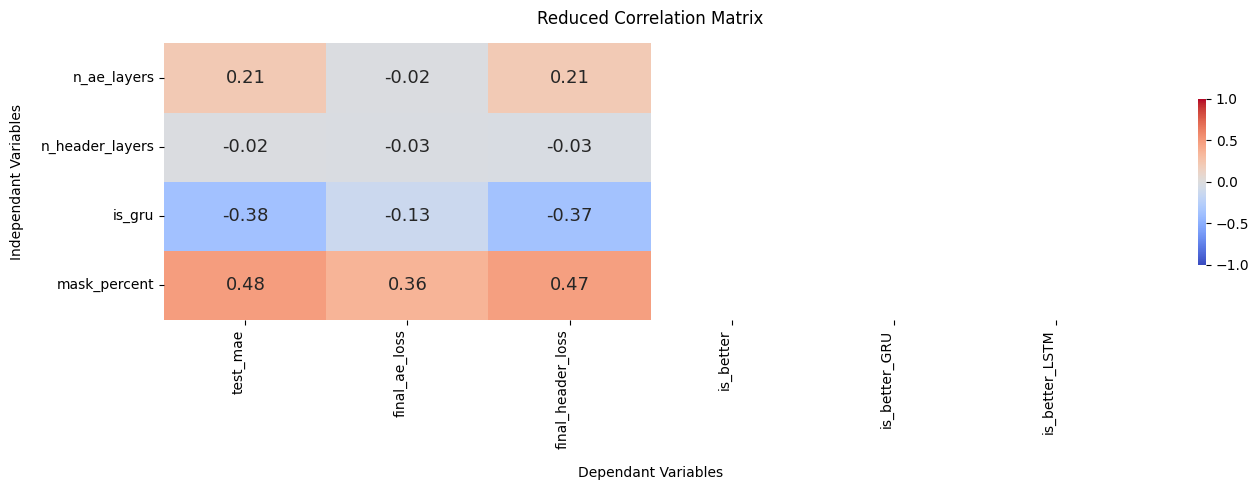

In [7]:
set_bottom = dependant_variables
set_right = independant_variables

A = df[set_right].values
B = df[set_bottom].values

corr = np.corrcoef(A.T, B.T)
corr_mat = corr[:len(set_right), len(set_right):]

corr_df = pd.DataFrame(corr_mat, index=set_right, columns=set_bottom)

# Create figure and axes
fig, ax = plt.subplots(figsize=(14, 5))   # wider figure to fit long x-labels

# Plot heatmap
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    ax=ax,
    cbar_kws={"shrink": 0.6},
    annot_kws={"fontsize": 13}              # reduce annotation font size if crowded
)

# Tweak tick labels so they don't get cut off
ax.set_xlabel("Dependant Variables", labelpad=12)
ax.set_ylabel("Independant Variables", labelpad=12)
ax.set_title("Reduced Correlation Matrix", pad=14)

# Rotate and right-align x tick labels (long names)
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)

# Optionally reduce x tick label font size if still crowded
for tick in ax.get_xticklabels():
    tick.set_fontsize(10)

# Tight layout and save without clipping
plt.tight_layout()
plt.savefig("reduced_corr_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

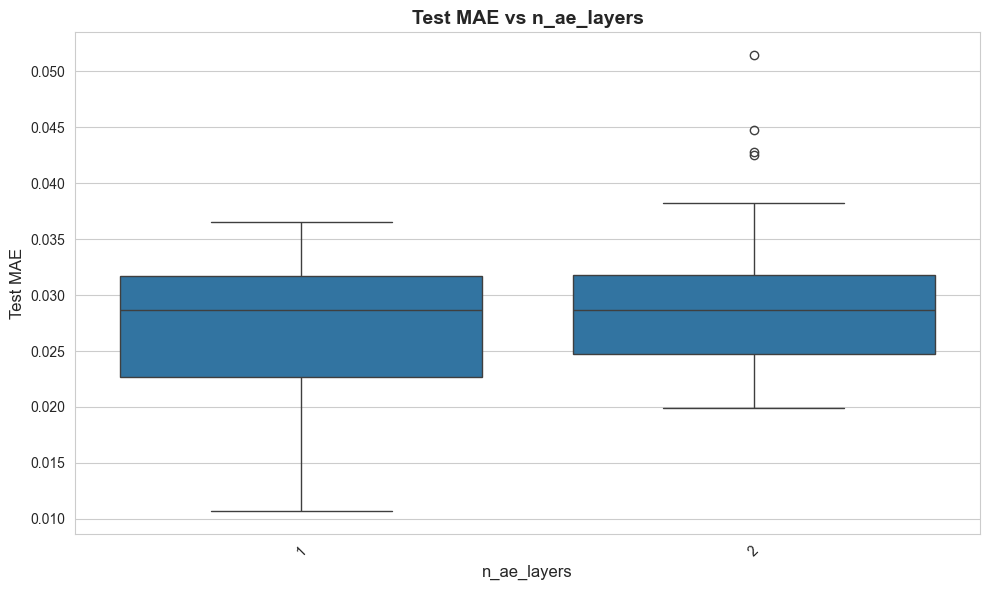

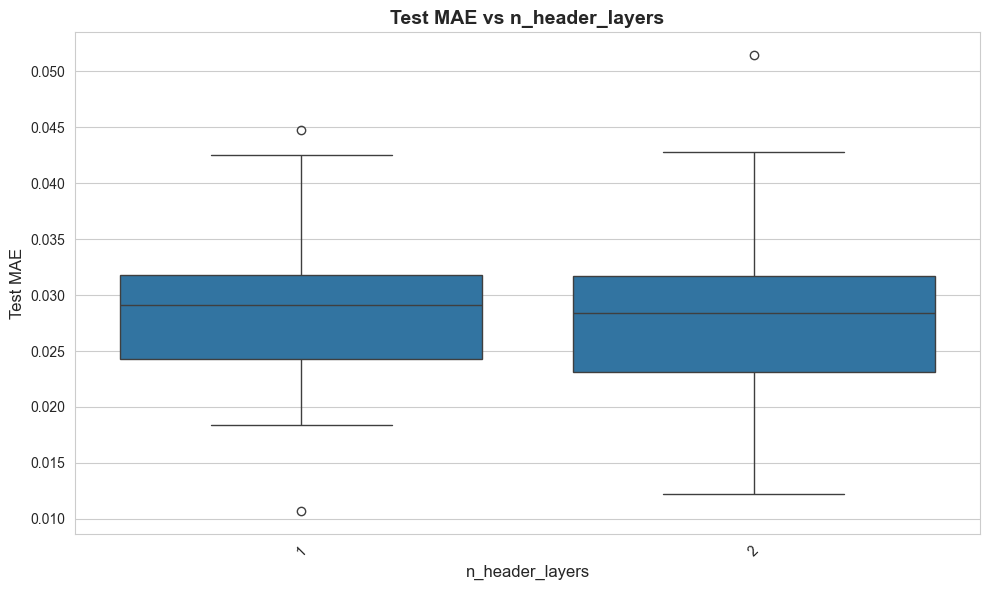

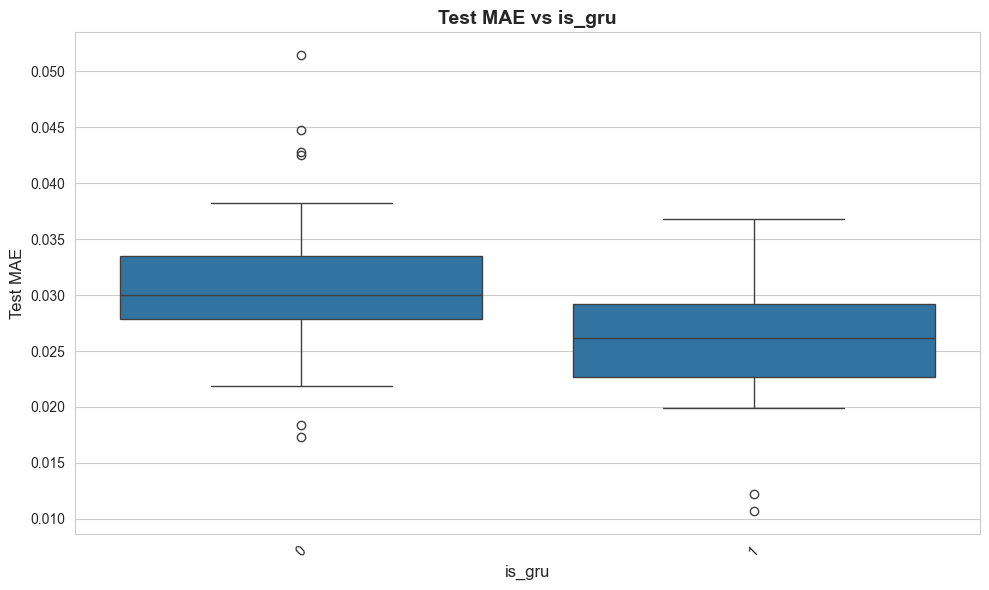

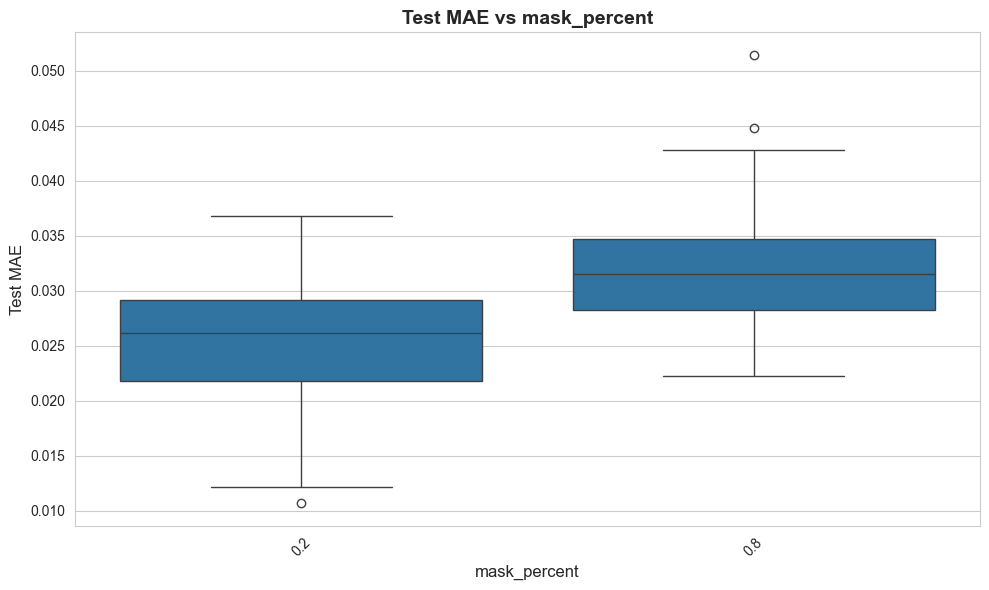

In [8]:
sns.set_style("whitegrid")

for var in independant_variables:
    plt.figure(figsize=(10, 6))
    
    n_unique = df[var].nunique()
    
    if n_unique <= 10:  # Categorical or few unique values
        sns.boxplot(data=df, x=var, y='test_mae')
    else:  # Continuous variable
        sns.scatterplot(data=df, x=var, y='test_mae', alpha=0.6)
        # Add a trend line
        sns.regplot(data=df, x=var, y='test_mae', scatter=False, color='red')
    
    plt.title(f'Test MAE vs {var}', fontsize=14, fontweight='bold')
    plt.xlabel(var, fontsize=12)
    plt.ylabel('Test MAE', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()